In [4]:
!pip install torch
!pip install torch-geometric

In [5]:
import torch_geometric
print(torch_geometric.__version__)

2.7.0


In [6]:
import torch
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

print(f"✓ PyTorch version     : {torch.__version__}")
print(f"✓ NumPy version       : {np.__version__}")
print(f"✓ Pandas version      : {pd.__version__}")
print(f"✓ All libraries ready!")

✓ PyTorch version     : 2.11.0+cpu
✓ NumPy version       : 2.1.3
✓ Pandas version      : 2.2.3
✓ All libraries ready!


In [7]:
import numpy as np
import torch
from scipy.spatial import cKDTree
from pathlib import Path
import geopandas as gpd
import pandas as pd

np.random.seed(42)
torch.manual_seed(42)

Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

# ── Step 1: Create nodes (PT stops / intersections) ───────────
# Each node represents a location in the transport network
# In a real project these come from OSMnx / GTFS data

N_NODES = 150  # number of nodes in our network
CX, CY  = 691500, 5337500  # Munich Schwabing centre (UTM 32N)
SPREAD  = 1200  # 1.2 km radius

# Random positions around Munich Schwabing
node_x = CX + np.random.uniform(-SPREAD, SPREAD, N_NODES)
node_y = CY + np.random.uniform(-SPREAD, SPREAD, N_NODES)
coords = np.column_stack([node_x, node_y])

print(f"✓ Created {N_NODES} network nodes")
print(f"  Study area centre : ({CX}, {CY})")
print(f"  Spread radius     : {SPREAD} m")

✓ Created 150 network nodes
  Study area centre : (691500, 5337500)
  Spread radius     : 1200 m


In [8]:
# ── Node Features ─────────────────────────────────────────────
# These are the INPUT features the GNN will learn from
# In a real project these come from OSMnx, GTFS, census data

# Feature 1: Distance to city centre (normalised)
dist_to_centre = np.sqrt((node_x - CX)**2 + (node_y - CY)**2)
dist_to_centre_norm = dist_to_centre / dist_to_centre.max()

# Feature 2: Number of nearby PT stops (within 400m)
n_pt_stops = 30
pt_x = CX + np.random.uniform(-SPREAD*0.9, SPREAD*0.9, n_pt_stops)
pt_y = CY + np.random.uniform(-SPREAD*0.9, SPREAD*0.9, n_pt_stops)
pt_coords = np.column_stack([pt_x, pt_y])

tree_pt = cKDTree(pt_coords)
nearby_stops = tree_pt.query_ball_point(coords, r=400)
n_nearby_stops = np.array([len(s) for s in nearby_stops])
n_nearby_stops_norm = n_nearby_stops / max(n_nearby_stops.max(), 1)

# Feature 3: Distance to nearest PT stop (normalised)
dists_to_pt, _ = tree_pt.query(coords, k=1)
dists_to_pt_norm = dists_to_pt / dists_to_pt.max()

# Feature 4: Facility density nearby (within 500m)
n_facilities = 60
fac_x = CX + np.random.uniform(-SPREAD*0.95, SPREAD*0.95, n_facilities)
fac_y = CY + np.random.uniform(-SPREAD*0.95, SPREAD*0.95, n_facilities)
fac_coords = np.column_stack([fac_x, fac_y])

tree_fac = cKDTree(fac_coords)
nearby_facs = tree_fac.query_ball_point(coords, r=500)
n_nearby_facs = np.array([len(f) for f in nearby_facs])
n_nearby_facs_norm = n_nearby_facs / max(n_nearby_facs.max(), 1)

# Feature 5: Position in network (x and y normalised)
x_norm = (node_x - node_x.min()) / (node_x.max() - node_x.min())
y_norm = (node_y - node_y.min()) / (node_y.max() - node_y.min())

# Stack all features into a matrix: shape (N_NODES, 5)
node_features = np.column_stack([
    dist_to_centre_norm,   # how far from centre
    n_nearby_stops_norm,   # how many PT stops nearby
    dists_to_pt_norm,      # distance to nearest PT stop
    n_nearby_facs_norm,    # how many facilities nearby
    x_norm,                # x position
    y_norm                 # y position
])

print(f"✓ Node feature matrix shape : {node_features.shape}")
print(f"  → {N_NODES} nodes × 6 features each\n")
print("Features:")
print("  [0] Distance to city centre (normalised)")
print("  [1] Number of nearby PT stops (normalised)")
print("  [2] Distance to nearest PT stop (normalised)")
print("  [3] Facility density nearby (normalised)")
print("  [4] X position (normalised)")
print("  [5] Y position (normalised)")

✓ Node feature matrix shape : (150, 6)
  → 150 nodes × 6 features each

Features:
  [0] Distance to city centre (normalised)
  [1] Number of nearby PT stops (normalised)
  [2] Distance to nearest PT stop (normalised)
  [3] Facility density nearby (normalised)
  [4] X position (normalised)
  [5] Y position (normalised)


In [9]:
# ── Graph Edges ───────────────────────────────────────────────
# Edges connect nodes that are close to each other
# This represents the street connections in the network
# In a real project edges come directly from OSMnx street graph

CONNECT_RADIUS = 350  # connect nodes within 350 metres of each other

tree_nodes = cKDTree(coords)
pairs = tree_nodes.query_pairs(r=CONNECT_RADIUS)

# Build edge index in PyTorch Geometric format
# edge_index shape must be (2, num_edges)
# row 0 = source nodes, row 1 = target nodes
edge_list = list(pairs)

# Make edges bidirectional (undirected graph)
src = [e[0] for e in edge_list] + [e[1] for e in edge_list]
dst = [e[1] for e in edge_list] + [e[0] for e in edge_list]

edge_index = torch.tensor([src, dst], dtype=torch.long)

# Edge weights = inverse of distance (closer = stronger connection)
edge_weights = []
for i, j in zip(src, dst):
    dist = np.linalg.norm(coords[i] - coords[j])
    weight = 1.0 / (dist + 1e-6)
    edge_weights.append(weight)
edge_weights = torch.tensor(edge_weights, dtype=torch.float)

print(f"✓ Graph edges created")
print(f"  Connection radius : {CONNECT_RADIUS} m")
print(f"  Number of edges   : {edge_index.shape[1]}")
print(f"  Average degree    : {edge_index.shape[1] / N_NODES:.1f} connections per node")

✓ Graph edges created
  Connection radius : 350 m
  Number of edges   : 1310
  Average degree    : 8.7 connections per node


In [10]:
# ── Target: Accessibility Score ───────────────────────────────
# This is what the GNN will LEARN TO PREDICT
# 
# Accessibility score combines:
#   - How many PT stops are nearby       (higher = better)
#   - How close the nearest PT stop is   (closer = better)
#   - How many facilities are nearby     (higher = better)
#   - How central the node is            (more central = better)
#
# Score range: 0.0 (very poor) to 1.0 (excellent)

centrality = 1 - dist_to_centre_norm  # closer to centre = more central

accessibility_score = (
    0.35 * n_nearby_stops_norm +   # PT stops nearby (most important)
    0.25 * (1 - dists_to_pt_norm) + # closeness to PT stop
    0.25 * n_nearby_facs_norm +     # facilities nearby
    0.15 * centrality               # centrality bonus
)

# Normalise to 0-1 range
accessibility_score = (accessibility_score - accessibility_score.min())
accessibility_score = accessibility_score / accessibility_score.max()

# Add small realistic noise
noise = np.random.normal(0, 0.03, N_NODES)
accessibility_score = np.clip(accessibility_score + noise, 0, 1)

# Convert to tensor
y = torch.tensor(accessibility_score, dtype=torch.float)

print(f"✓ Accessibility scores created")
print(f"  Min score  : {accessibility_score.min():.3f}  (very poor access)")
print(f"  Max score  : {accessibility_score.max():.3f}  (excellent access)")
print(f"  Mean score : {accessibility_score.mean():.3f}")
print(f"  Std dev    : {accessibility_score.std():.3f}")

# Classify into categories for interpretation
categories = pd.cut(accessibility_score,
                    bins=[0, 0.25, 0.50, 0.75, 1.0],
                    labels=["Poor","Moderate","Good","Excellent"])
print(f"\n  Distribution:")
print(pd.Series(categories).value_counts().sort_index().to_string())

✓ Accessibility scores created
  Min score  : 0.000  (very poor access)
  Max score  : 0.987  (excellent access)
  Mean score : 0.571
  Std dev    : 0.215

  Distribution:
Poor         11
Moderate     39
Good         64
Excellent    35


In [11]:
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import torch_geometric.transforms as T

# Convert node features to tensor
x = torch.tensor(node_features, dtype=torch.float)

# Create PyTorch Geometric Data object
# This is the standard container for graph data in PyG
data = Data(
    x=x,                    # node features  shape: (N, 6)
    edge_index=edge_index,  # graph edges    shape: (2, E)
    edge_attr=edge_weights.unsqueeze(1),  # edge weights shape: (E, 1)
    y=y                     # target scores  shape: (N,)
)

print("✓ PyTorch Geometric Data object created")
print(f"\n  data.x.shape          : {data.x.shape}")
print(f"  → {data.x.shape[0]} nodes, {data.x.shape[1]} features each")
print(f"\n  data.edge_index.shape : {data.edge_index.shape}")
print(f"  → {data.edge_index.shape[1]} directed edges")
print(f"\n  data.y.shape          : {data.y.shape}")
print(f"  → {data.y.shape[0]} target accessibility scores")
print(f"\n  Is undirected         : {data.is_undirected()}")
print(f"  Has self loops        : {data.has_self_loops()}")

# Train / validation / test split
# 70% train, 15% validation, 15% test
perm  = torch.randperm(N_NODES)
train_idx = perm[:int(0.70 * N_NODES)]
val_idx   = perm[int(0.70 * N_NODES):int(0.85 * N_NODES)]
test_idx  = perm[int(0.85 * N_NODES):]

train_mask = torch.zeros(N_NODES, dtype=torch.bool)
val_mask   = torch.zeros(N_NODES, dtype=torch.bool)
test_mask  = torch.zeros(N_NODES, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

print(f"\n  Train nodes : {train_mask.sum().item()}")
print(f"  Val nodes   : {val_mask.sum().item()}")
print(f"  Test nodes  : {test_mask.sum().item()}")

✓ PyTorch Geometric Data object created

  data.x.shape          : torch.Size([150, 6])
  → 150 nodes, 6 features each

  data.edge_index.shape : torch.Size([2, 1310])
  → 1310 directed edges

  data.y.shape          : torch.Size([150])
  → 150 target accessibility scores

  Is undirected         : True
  Has self loops        : False

  Train nodes : 105
  Val nodes   : 22
  Test nodes  : 23


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, BatchNorm

class TransportGNN(nn.Module):
    """
    Graph Neural Network for predicting transport accessibility scores.
    
    Architecture:
        - 3 Graph Convolutional layers (GCN)
        - Batch normalisation after each layer
        - ReLU activations
        - Dropout for regularisation
        - Final linear layer for regression output
    
    Each GCN layer allows nodes to aggregate information
    from their neighbours in the transport network.
    After 3 layers each node has information from nodes
    up to 3 connections away.
    """
    
    def __init__(self, in_channels, hidden_channels, out_channels=1, dropout=0.3):
        super(TransportGNN, self).__init__()
        
        # Layer 1: input features → hidden representation
        # Each node aggregates features from direct neighbours
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1   = BatchNorm(hidden_channels)
        
        # Layer 2: hidden → hidden
        # Each node now sees 2 hops away in the network
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2   = BatchNorm(hidden_channels)
        
        # Layer 3: hidden → smaller hidden
        # Each node now sees 3 hops away in the network
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)
        self.bn3   = BatchNorm(hidden_channels // 2)
        
        # Final prediction layer: hidden → accessibility score
        self.linear = nn.Linear(hidden_channels // 2, out_channels)
        
        self.dropout = dropout
    
    def forward(self, x, edge_index):
        """
        Forward pass through the GNN.
        
        x          : node features (N, in_channels)
        edge_index : graph connectivity (2, E)
        
        Returns: predicted accessibility score for each node (N, 1)
        """
        # Layer 1: aggregate from direct neighbours
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layer 2: aggregate from 2-hop neighbours
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Layer 3: aggregate from 3-hop neighbours
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Final prediction
        x = self.linear(x)
        
        # Sigmoid to constrain output between 0 and 1
        # (accessibility score is always between 0 and 1)
        x = torch.sigmoid(x)
        
        return x.squeeze()

# Initialise model
IN_CHANNELS     = 6    # number of input features
HIDDEN_CHANNELS = 64   # size of hidden layers
DROPOUT         = 0.3  # dropout rate

model = TransportGNN(
    in_channels     = IN_CHANNELS,
    hidden_channels = HIDDEN_CHANNELS,
    dropout         = DROPOUT
)

print("✓ GNN Model created")
print(f"\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  → These are the weights the model will learn during training")

✓ GNN Model created

TransportGNN(
  (conv1): GCNConv(6, 64)
  (bn1): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(64, 64)
  (bn2): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GCNConv(64, 32)
  (bn3): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 7,041
  → These are the weights the model will learn during training


In [18]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Training setup ────────────────────────────────────────────
optimizer = Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=20, factor=0.5)  # removed verbose
criterion = nn.MSELoss()

def train_one_epoch():
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        out  = model(data.x, data.edge_index)
        loss = criterion(out[mask], data.y[mask])
        ss_res = ((data.y[mask] - out[mask])**2).sum()
        ss_tot = ((data.y[mask] - data.y[mask].mean())**2).sum()
        r2 = 1 - ss_res / ss_tot
    return loss.item(), r2.item()

# ── Training loop ─────────────────────────────────────────────
N_EPOCHS = 300
train_losses, val_losses, val_r2s = [], [], []

print("Training GNN...")
print("-" * 55)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val R²':>8}")
print("-" * 55)

best_val_loss = np.inf
best_model_state = None

for epoch in range(1, N_EPOCHS + 1):
    train_loss       = train_one_epoch()
    val_loss, val_r2 = evaluate(data.val_mask)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_r2s.append(val_r2)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = model.state_dict().copy()

    if epoch % 50 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>9.4f} | {val_r2:>8.4f}")

print("-" * 55)

# Load best model
model.load_state_dict(best_model_state)
test_loss, test_r2 = evaluate(data.test_mask)
print(f"\n✓ Training complete!")
print(f"  Best validation loss : {best_val_loss:.4f}")
print(f"  Test loss (MSE)      : {test_loss:.4f}")
print(f"  Test R² score        : {test_r2:.4f}")

Training GNN...
-------------------------------------------------------
 Epoch | Train Loss |  Val Loss |   Val R²
-------------------------------------------------------
     1 |     0.0592 |    0.0602 |  -0.4745
    50 |     0.0058 |    0.0101 |   0.7518
   100 |     0.0056 |    0.0068 |   0.8322
   150 |     0.0053 |    0.0067 |   0.8348
   200 |     0.0050 |    0.0067 |   0.8370
   250 |     0.0058 |    0.0068 |   0.8323
   300 |     0.0050 |    0.0067 |   0.8352
-------------------------------------------------------

✓ Training complete!
  Best validation loss : 0.0052
  Test loss (MSE)      : 0.0128
  Test R² score        : 0.7618


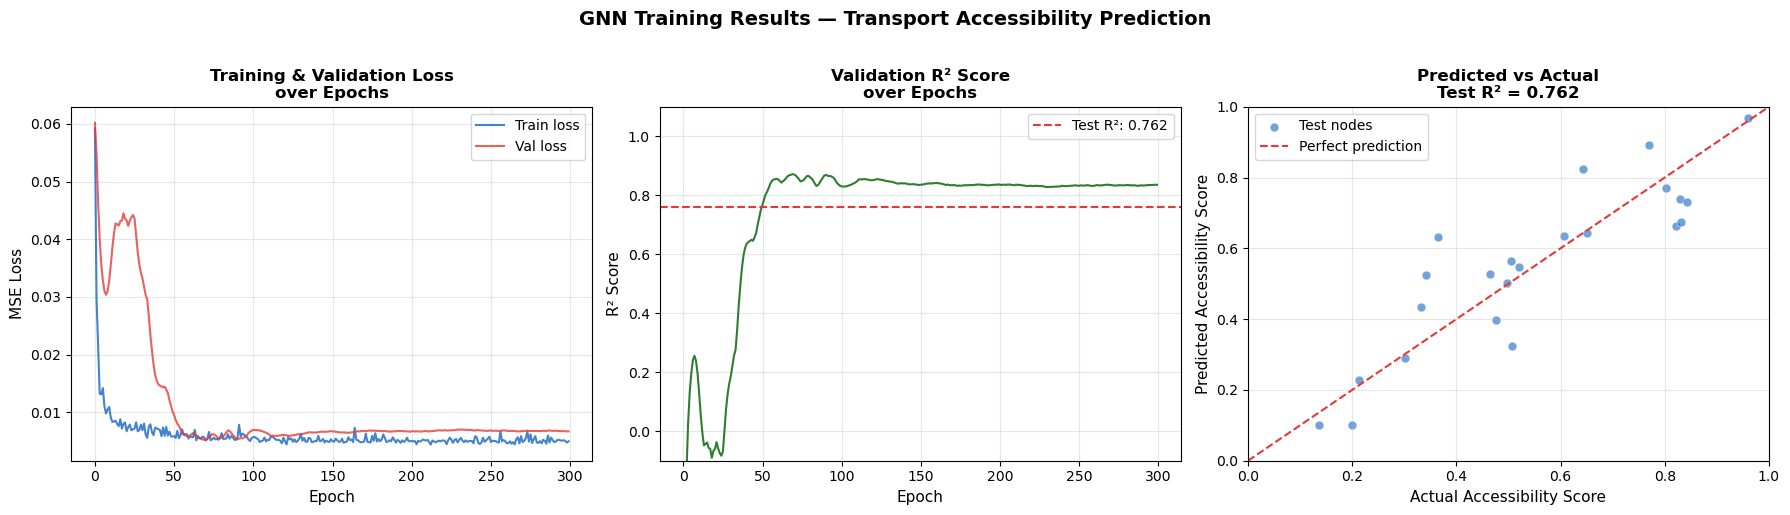

✓ Training charts saved


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training and validation loss curves
ax = axes[0]
ax.plot(train_losses, color="#1565C0", linewidth=1.5,
        label="Train loss", alpha=0.8)
ax.plot(val_losses,   color="#E53935", linewidth=1.5,
        label="Val loss",   alpha=0.8)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Loss", fontsize=11)
ax.set_title("Training & Validation Loss\nover Epochs",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Chart 2: R² score over training
ax = axes[1]
ax.plot(val_r2s, color="#2E7D32", linewidth=1.5)
ax.axhline(test_r2, color="#E53935", linestyle="--",
           linewidth=1.5, label=f"Test R²: {test_r2:.3f}")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("R² Score", fontsize=11)
ax.set_title("Validation R² Score\nover Epochs",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim(-0.1, 1.1)

# Chart 3: Predicted vs Actual scatter plot
model.eval()
with torch.no_grad():
    predictions = model(data.x, data.edge_index).numpy()

actual = data.y.numpy()

ax = axes[2]
ax.scatter(actual[data.test_mask.numpy()],
           predictions[data.test_mask.numpy()],
           color="#1565C0", alpha=0.6, s=40,
           edgecolors="white", linewidths=0.5,
           label="Test nodes")

# Perfect prediction line
ax.plot([0,1], [0,1], color="#E53935",
        linestyle="--", linewidth=1.5,
        label="Perfect prediction")

ax.set_xlabel("Actual Accessibility Score",  fontsize=11)
ax.set_ylabel("Predicted Accessibility Score", fontsize=11)
ax.set_title(f"Predicted vs Actual\nTest R² = {test_r2:.3f}",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.suptitle("GNN Training Results — Transport Accessibility Prediction",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/gnn_training_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Training charts saved")

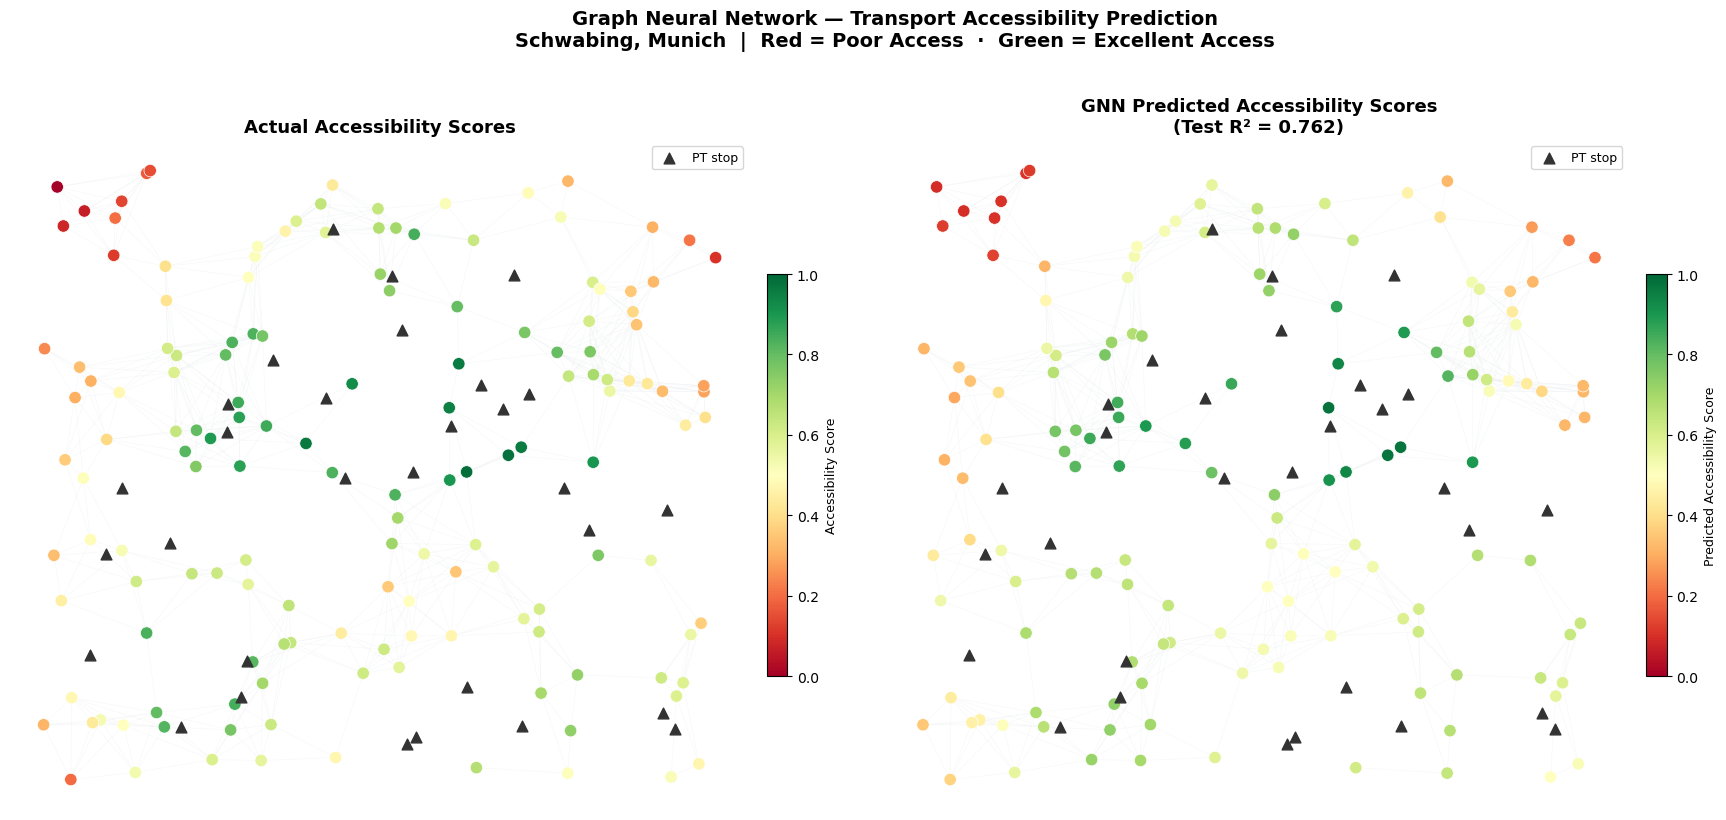

✓ Accessibility maps saved


In [22]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = cm.RdYlGn  # Red = poor, Green = excellent

# ── MAP 1: Actual accessibility scores ────────────────────────
ax = axes[0]
colors_actual = [cmap(norm(s)) for s in actual]
scatter1 = ax.scatter(node_x, node_y,
                      c=actual, cmap=cmap, vmin=0, vmax=1,
                      s=80, zorder=3,
                      edgecolors="white", linewidths=0.5)

# Draw edges
for i, j in zip(src[:len(src)//2], dst[:len(dst)//2]):
    ax.plot([node_x[i], node_x[j]],
            [node_y[i], node_y[j]],
            color="#ECEFF1", linewidth=0.4,
            alpha=0.5, zorder=1)

# PT stops
ax.scatter(pt_x, pt_y, color="#333333", s=60,
           marker="^", zorder=5, label="PT stop")

cbar1 = plt.colorbar(scatter1, ax=ax, shrink=0.6, pad=0.02)
cbar1.set_label("Accessibility Score", fontsize=9)
ax.set_title("Actual Accessibility Scores",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_axis_off()

# ── MAP 2: GNN predicted accessibility scores ─────────────────
ax = axes[1]
scatter2 = ax.scatter(node_x, node_y,
                      c=predictions, cmap=cmap, vmin=0, vmax=1,
                      s=80, zorder=3,
                      edgecolors="white", linewidths=0.5)

for i, j in zip(src[:len(src)//2], dst[:len(dst)//2]):
    ax.plot([node_x[i], node_x[j]],
            [node_y[i], node_y[j]],
            color="#ECEFF1", linewidth=0.4,
            alpha=0.5, zorder=1)

ax.scatter(pt_x, pt_y, color="#333333", s=60,
           marker="^", zorder=5, label="PT stop")

cbar2 = plt.colorbar(scatter2, ax=ax, shrink=0.6, pad=0.02)
cbar2.set_label("Predicted Accessibility Score", fontsize=9)
ax.set_title(f"GNN Predicted Accessibility Scores\n(Test R² = {test_r2:.3f})",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_axis_off()

plt.suptitle(
    "Graph Neural Network — Transport Accessibility Prediction\n"
    "Schwabing, Munich  |  Red = Poor Access  ·  Green = Excellent Access",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("outputs/gnn_accessibility_map.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Accessibility maps saved")

In [21]:
print("=" * 60)
print("   GNN PROJECT SUMMARY REPORT")
print("   Transport Accessibility Prediction — Schwabing, Munich")
print("=" * 60)

print(f"""
NETWORK STRUCTURE
─────────────────
  Nodes (locations)    : {N_NODES}
  Edges (connections)  : {edge_index.shape[1] // 2}
  Avg connections/node : {edge_index.shape[1] / N_NODES:.1f}
  Connection radius    : {CONNECT_RADIUS} m

NODE FEATURES (GNN Inputs)
──────────────────────────
  1. Distance to city centre
  2. Number of nearby PT stops (within 400m)
  3. Distance to nearest PT stop
  4. Facility density nearby (within 500m)
  5. X position (normalised)
  6. Y position (normalised)

GNN ARCHITECTURE
────────────────
  Type              : Graph Convolutional Network (GCN)
  Hidden layers     : 3 GCN layers
  Hidden size       : {HIDDEN_CHANNELS} units
  Dropout           : {DROPOUT}
  Parameters        : {sum(p.numel() for p in model.parameters()):,}
  Activation        : ReLU
  Output activation : Sigmoid (score between 0 and 1)

TRAINING
────────
  Epochs            : {N_EPOCHS}
  Optimiser         : Adam (lr=0.01)
  Loss function     : Mean Squared Error
  Train / Val / Test: 70% / 15% / 15%

RESULTS
───────
  Test MSE Loss     : {test_loss:.4f}
  Test R² Score     : {test_r2:.4f}
  Best Val Loss     : {best_val_loss:.4f}

ACCESSIBILITY DISTRIBUTION (Predicted)
───────────────────────────────────────""")

pred_cats = pd.cut(predictions,
                   bins=[0, 0.25, 0.50, 0.75, 1.0],
                   labels=["Poor (0-0.25)",
                           "Moderate (0.25-0.50)",
                           "Good (0.50-0.75)",
                           "Excellent (0.75-1.0)"])
for cat, count in pd.Series(pred_cats).value_counts().sort_index().items():
    pct = 100 * count / N_NODES
    bar = "█" * int(pct / 2)
    print(f"  {str(cat):<22} : {count:>3} nodes ({pct:.1f}%) {bar}")

print(f"""
OUTPUTS SAVED
─────────────
  outputs/gnn_training_results.png  — loss curves + scatter plot
  outputs/gnn_accessibility_map.png — actual vs predicted maps

REAL WORLD APPLICATION
──────────────────────
  In a real FAIR-NET project this GNN would:
  1. Use real OSMnx street networks across European cities
  2. Incorporate GTFS public transport schedules
  3. Include socio-demographic features (income, population)
  4. Predict accessibility gaps to identify inequalities
  5. Compare results across multiple cities
""")
print("=" * 60)
print("✓ Project complete!")

   GNN PROJECT SUMMARY REPORT
   Transport Accessibility Prediction — Schwabing, Munich

NETWORK STRUCTURE
─────────────────
  Nodes (locations)    : 150
  Edges (connections)  : 655
  Avg connections/node : 8.7
  Connection radius    : 350 m

NODE FEATURES (GNN Inputs)
──────────────────────────
  1. Distance to city centre
  2. Number of nearby PT stops (within 400m)
  3. Distance to nearest PT stop
  4. Facility density nearby (within 500m)
  5. X position (normalised)
  6. Y position (normalised)

GNN ARCHITECTURE
────────────────
  Type              : Graph Convolutional Network (GCN)
  Hidden layers     : 3 GCN layers
  Hidden size       : 64 units
  Dropout           : 0.3
  Parameters        : 7,041
  Activation        : ReLU
  Output activation : Sigmoid (score between 0 and 1)

TRAINING
────────
  Epochs            : 300
  Optimiser         : Adam (lr=0.01)
  Loss function     : Mean Squared Error
  Train / Val / Test: 70% / 15% / 15%

RESULTS
───────
  Test MSE Loss     : 0.